# Bulk Topological Invariants of the SSH Lattice
## Winding Number Analysis

This notebook performs a bulk topological characterization
of the SSH lattice using:

1. Winding number (geometric interpretation)

The purpose is to identify parameter regimes that support
topologically nontrivial phases, which later manifest as
edge-localized states in finite systems.

In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import yaml
import json
import hashlib
from pathlib import Path

In [2]:
def load_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

CONFIG_DIR = Path("..") / "config"

global_config = load_yaml(CONFIG_DIR / "global_config.yaml")
lattice_config = load_yaml(CONFIG_DIR / "lattice_params.yaml")
simulation_config = load_yaml(CONFIG_DIR / "simulation_params.yaml")
plotting_config = load_yaml(CONFIG_DIR / "plotting_params.yaml")

NOTEBOOK_KEY = "02_topological_invariants"
assert NOTEBOOK_KEY in plotting_config["notebook_figures"]

In [3]:
num_cells = lattice_config["lattice"]["num_unit_cells"]
t1 = lattice_config["couplings"]["intra_cell"]
t2 = lattice_config["couplings"]["inter_cell"]

gamma_a = lattice_config["non_hermiticity"]["gain"]["strength"]
gamma_b = lattice_config["non_hermiticity"]["loss"]["strength"]

## Non-Hermitian SSH Bloch Hamiltonian

We consider a non-Hermitian Su–Schrieffer–Heeger (SSH) model with **asymmetric
gain and loss**, described by a two-band Bloch Hamiltonian of the form

$$
H(k) =
\begin{pmatrix}
i\gamma_a & t_1 + t_2 e^{-ik} \\
t_1 + t_2 e^{ik} & -i\gamma_b
\end{pmatrix},
$$

where:
- $$t_1$$ is the intra-cell hopping amplitude,
- $$t_2$$ is the inter-cell hopping amplitude,
- $$\gamma_a$$ denotes the gain strength on the A sublattice,
- $$\gamma_b$$ denotes the loss strength on the B sublattice,
- $$k \in [-\pi, \pi)$$ is the crystal momentum.

The presence of unequal gain and loss on the two sublattices renders the
Hamiltonian non-Hermitian and leads to complex energy eigenvalues. In contrast
to the Hermitian SSH model, the spectrum may exhibit exceptional points and
non-orthogonal eigenstates.

Importantly, the **bulk topological phase** of the system is determined solely
by the hopping amplitudes $$t_1$$ and $$t_2$$, while the gain–loss parameters
$$\gamma_a$$ and $$\gamma_b$$ modify the spectral properties without altering
the bulk topological invariant.

In [4]:
# Bloch SSH Hamiltonian (YAML-consistent)

def H_k_func(k):
    """
    Bloch Hamiltonian for non-Hermitian SSH model
    Uses YAML parameters:
        t1        : intra-cell hopping
        t2        : inter-cell hopping
        gamma_a  : gain on A sublattice
        gamma_b  : loss on B sublattice
    """
    offdiag = t1 + t2 * np.exp(-1j * k)

    return np.array([
        [1j * gamma_a, offdiag],
        [np.conj(offdiag), -1j * gamma_b]
    ], dtype=np.complex128)

# Topological Phase Transition

## Evaluating the winding number yields the following result:

$$
\nu =
\begin{cases}
0, & t_2 < t_1 \quad \text{(topologically trivial phase)}, \\
\pm 1, & t_2 > t_1 \quad \text{(topologically non-trivial phase)}.
\end{cases}
$$

Thus, the **topological phase transition occurs at**

$$
\frac{t_2}{t_1} = 1,
$$

where the bulk energy gap closes.

The sign of $$\nu$$ depends on the chosen Bloch convention and has no physical
consequence; the topology is fully characterized by $$|\nu|$$.

Importantly, the gain–loss parameter $$\gamma$$ does **not** affect the value
of the winding number, as it enters only through diagonal terms in the
Hamiltonian.

---

In [5]:
# Winding number 

def winding_number_from_Hk(num_k=2000):
    """
    Robust winding number for non-Hermitian SSH model.
    Topology is determined by the winding of the
    off-diagonal Bloch Hamiltonian element.

    Returns:
        winding number (integer, magnitude gives topology)
    """

    k_vals = np.linspace(-np.pi, np.pi, num_k, endpoint=False)

    # Off-diagonal term q(k)
    q_vals = t1 + t2 * np.exp(+1j * k_vals)

    # Phase winding
    phases = np.unwrap(np.angle(q_vals))
    winding = (phases[-1] - phases[0]) / (2 * np.pi)

    return int(np.round(winding))

In [6]:
nu = winding_number_from_Hk()
print("Winding number =", nu)
print("Topological =", abs(nu) == 1)

Winding number = 1
Topological = True


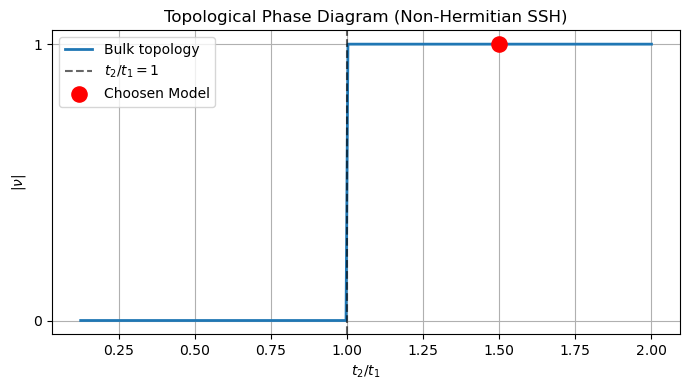

PosixPath('figures/02_topological_invariants/nonhermitian_topological_phase_diagram.png')

In [7]:
# Utilities

def ensure_directory(path):
    Path(path).mkdir(parents=True, exist_ok=True)

def save_figure(fig, notebook_key, filename, plotting_config):
    cfg = plotting_config["notebook_figures"][notebook_key]
    output_dir = Path(cfg["output_dir"])
    ensure_directory(output_dir)
    ext = plotting_config["global"]["figure_format"]
    dpi = plotting_config["global"]["dpi"]
    path = output_dir / f"{filename}.{ext}"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    return path

# Bloch SSH Hamiltonian (YAML-CONSISTENT)

def bloch_ssh_hamiltonian(k, t1, t2, gamma_a, gamma_b):
    """
    Non-Hermitian SSH Bloch Hamiltonian

    A sublattice : +i gamma_a (gain)
    B sublattice : -i gamma_b (loss)
    """
    offdiag = t1 + t2 * np.exp(-1j * k)

    return np.array([
        [1j * gamma_a, offdiag],
        [np.conj(offdiag), -1j * gamma_b]
    ], dtype=np.complex128)


# Winding number 

def winding_number_from_yaml(t1, t2, num_k=2000):
    """
    Bulk winding number for SSH model.
    Depends ONLY on hopping ratio t2/t1.
    """

    k_vals = np.linspace(-np.pi, np.pi, num_k, endpoint=False)

    # Off-diagonal Bloch Hamiltonian element
    q_vals = t1 + t2 * np.exp(-1j * k_vals)

    phases = np.unwrap(np.angle(q_vals))
    winding = (phases[-1] - phases[0]) / (2 * np.pi)

    # magnitude defines topology
    return abs(int(np.round(winding)))


# Phase diagram (YAML-DRIVEN)

t1_ref = t1
t2_vals = np.linspace(0.1, 2.0 * t1_ref, 300)

winding_vals = [winding_number_from_yaml(t1_ref, t2v) for t2v in t2_vals]
yaml_ratio = t2 / t1


# Plot

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    t2_vals / t1_ref,
    winding_vals,
    lw=2,
    label="Bulk topology"
)

ax.axvline(
    1.0,
    color="k",
    ls="--",
    alpha=0.6,
    label=r"$t_2/t_1 = 1$"
)

# YAML operating point
ax.scatter(
    yaml_ratio,
    winding_number_from_yaml(t1, t2),
    color="red",
    s=120,
    zorder=5,
    label="Choosen Model"
)

ax.set_xlabel(r"$t_2 / t_1$")
ax.set_ylabel(r"$|\nu|$")
ax.set_yticks([0, 1])
ax.set_title("Topological Phase Diagram (Non-Hermitian SSH)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


# Save figure

fig_path = save_figure(
    fig,
    NOTEBOOK_KEY,
    "nonhermitian_topological_phase_diagram",
    plotting_config
)

fig_path


## Phase Diagram Interpretation

The topological phase diagram is therefore fully determined by the ratio

$$
\frac{t_2}{t_1}.
$$

- $$t_2 / t_1 < 1$$: trivial bulk phase $$\;(\nu = 0)$$,
- $$t_2 / t_1 > 1$$: topological bulk phase $$\;(|\nu| = 1)$$.

This phase diagram represents a **universal bulk property** of the SSH model.
Specific parameter values chosen in the configuration files (YAML) correspond
to particular points within this diagram.

## Bulk–Edge Correspondence

Although the winding number is defined for the periodic (bulk) system, its
physical consequences appear when open boundary conditions are imposed.
In the topological phase $$|\nu| = 1$$, the bulk–edge correspondence guarantees
the existence of localized edge modes.

In the non-Hermitian case, these edge states acquire complex energies and may
exhibit asymmetric localization due to gain and loss, while their **existence**
remains dictated by the bulk winding number.




## Bulk–Edge Correspondence

Although the winding number is defined for the periodic (bulk) system, its
physical consequences appear when open boundary conditions are imposed.
In the topological phase $$|\nu| = 1$$, the bulk–edge correspondence guarantees
the existence of localized edge modes.

In the non-Hermitian case, these edge states acquire complex energies and may
exhibit asymmetric localization due to gain and loss, while their **existence**
remains dictated by the bulk winding number.




## Summary

- The winding number $$\nu$$ is a **bulk topological invariant**.
- The topological phase transition occurs at $$t_2 / t_1 = 1$$.
- Gain and loss modify the spectrum but do not alter the bulk topology.
- Edge-localized states observed under open boundary conditions are direct
  manifestations of the bulk topological phase.